# Assignment 2: OpenCV Advanced Preprocessing and Feature Extraction
This notebook covers various image processing techniques including edge detection, contours, transforms, segmentation, and inpainting.

## 1. Canny Edge Detector
Write a Python script to apply the Canny edge detector on an image using OpenCV. Explain how the threshold values affect the result.

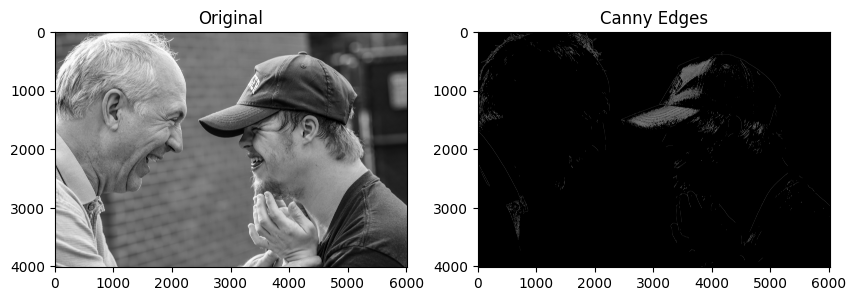

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv.imread('../assets/assignment.jpg', cv.IMREAD_GRAYSCALE)
if img is not None:
    # Apply Canny Edge Detector
    # minVal = 100, maxVal = 200
    edges = cv.Canny(img, 100, 200)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original')
    plt.subplot(1, 2, 2), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
    plt.show()
else:
    print("Please make sure the image path is correct.")

**Explanation:**
The Canny edge detector uses two threshold values, `minVal` and `maxVal`:
- Any edges with an intensity gradient above `maxVal` are sure to be edges.
- Any edges below `minVal` are sure to be non-edges, so they are discarded.
- Edges with a gradient between `minVal` and `maxVal` are classified as edges or non-edges based on their connectivity. If they are connected to 'sure edge' pixels, they are considered edges. Otherwise, they are discarded.
Thus, decreasing both thresholds detects more faint edges (but potentially more noise), while increasing them detects only the strongest edges.

## 2. Contour Processing
Given a binary image, write a function to detect and draw contours. How can you filter contours based on area?

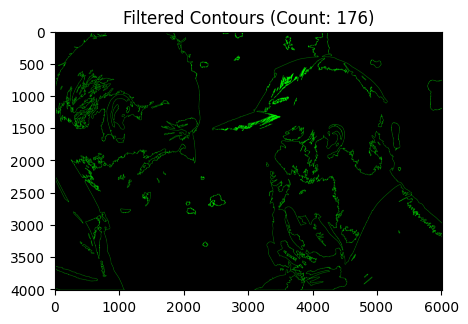

In [3]:
def process_contours(binary_img, min_area=100):
    # Detect contours
    contours, hierarchy = cv.findContours(binary_img, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on area
    filtered_contours = [c for c in contours if cv.contourArea(c) > min_area]
    
    # Draw contours on a blank image
    output_img = np.zeros_like(cv.cvtColor(binary_img, cv.COLOR_GRAY2BGR))
    cv.drawContours(output_img, filtered_contours, -1, (0, 255, 0), 2)
    
    return output_img, len(filtered_contours)

# Example usage (assuming 'img' is available and thresholded)
if img is not None:
    _, thresh = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
    contour_img, num_contours = process_contours(thresh, min_area=500)
    
    plt.figure(figsize=(5,5))
    plt.imshow(cv.cvtColor(contour_img, cv.COLOR_BGR2RGB))
    plt.title(f'Filtered Contours (Count: {num_contours})')
    plt.show()

**Explanation:**
Contours can be filtered using `cv2.contourArea(contour)`. By iterating through the detected contours, we can calculate the area of each and only keep those that are greater than (or less than) a specific threshold area. This is extremely useful for removing small noise spots or focusing only on large objects.

## 3. Hough Transform (Lines)
Write a script to detect straight lines in an image using `cv2.HoughLinesP`. How can you adjust parameters to detect more or fewer lines?

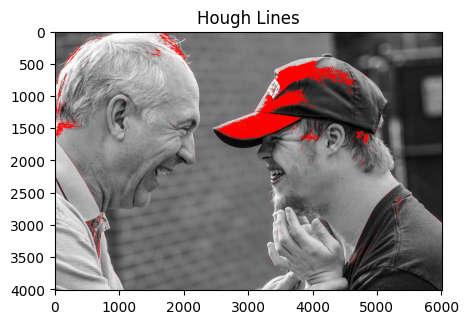

In [4]:
if img is not None:
    edges = cv.Canny(img, 50, 150)
    # rho=1, theta=pi/180, threshold=100, minLineLength=50, maxLineGap=10
    lines = cv.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)
    
    line_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv.line(line_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            
    plt.figure(figsize=(5,5))
    plt.imshow(cv.cvtColor(line_img, cv.COLOR_BGR2RGB))
    plt.title('Hough Lines')
    plt.show()

**Explanation:**
To detect **more lines**, you can:
- Decrease the `threshold`: The minimum number of intersections in the Hough accumulator to "detect" a line.
- Decrease `minLineLength`: The minimum length of a line segment. Shorter segments will be detected.
- Increase `maxLineGap`: The maximum allowed gap between points on the same line to link them. 
To detect **fewer lines**, you do the opposite (increase `threshold`, increase `minLineLength`, decrease `maxLineGap`).

## 4. Hough Circles
Implement circle detection using `cv2.HoughCircles`. What parameters affect the accuracy of detected circles?

In [ ]:
if img is not None:
    # Blurring is highly recommended before HoughCircles
    blurred = cv.medianBlur(img, 5)
    
    circles = cv.HoughCircles(blurred, cv.HOUGH_GRADIENT, dp=1, minDist=20,
                              param1=50, param2=30, minRadius=0, maxRadius=0)
    
    circle_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # draw the outer circle
            cv.circle(circle_img, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # draw the center of the circle
            cv.circle(circle_img, (i[0], i[1]), 2, (0, 0, 255), 3)
            
    plt.figure(figsize=(5,5))
    plt.imshow(cv.cvtColor(circle_img, cv.COLOR_BGR2RGB))
    plt.title('Hough Circles')
    plt.show()

**Explanation:**
The key parameters affecting accuracy are:
- `dp`: Inverse ratio of the accumulator resolution to the image resolution. Smaller `dp` means more precise center localization.
- `minDist`: Minimum distance between the centers of detected circles. If too small, multiple neighbor circles may be falsely detected. If too large, some circles may be missed.
- `param1`: The higher threshold for the internal Canny edge detector (the lower one is half of this).
- `param2`: The accumulator threshold for circle centers. A lower `param2` will detect more (and potentially false) circles. A higher `param2` will only return the most perfect circles.

## 5. Binary Thresholding
Convert an image to grayscale and apply binary thresholding. What happens when you change the threshold value?

In [ ]:
if img is not None:
    # Applying threshold of 100 and 200 to see the difference
    ret1, thresh1 = cv.threshold(img, 100, 255, cv.THRESH_BINARY)
    ret2, thresh2 = cv.threshold(img, 200, 255, cv.THRESH_BINARY)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1), plt.imshow(thresh1, cmap='gray'), plt.title('Threshold = 100')
    plt.subplot(1, 2, 2), plt.imshow(thresh2, cmap='gray'), plt.title('Threshold = 200')
    plt.show()

**Explanation:**
When you apply `cv2.threshold`, any pixel intensity greater than the threshold value is set to the maximum value (e.g., 255, white), and any pixel intensity less than or equal to the threshold is set to 0 (black).
- Increasing the threshold value requires pixels to be much brighter to become white, resulting in an overall darker binary image (more black pixels).
- Decreasing the threshold allows darker pixels to become white, resulting in a whiter binary image.

## 6. Gaussian vs Median Blurring
Given a noisy grayscale image, apply Gaussian and median blurring. Which works better for salt-and-pepper noise?

In [ ]:
# Create a noisy image (Salt and Pepper noise)
noisy = np.zeros((300, 300), dtype=np.uint8)
noise_points = np.random.rand(300, 300)
noisy[noise_points < 0.05] = 255  # Salt
noisy[noise_points > 0.95] = 0    # Pepper

gaussian_blur = cv.GaussianBlur(noisy, (5, 5), 0)
median_blur = cv.medianBlur(noisy, 5)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(noisy, cmap='gray'), plt.title('Noisy Image')
plt.subplot(1, 3, 2), plt.imshow(gaussian_blur, cmap='gray'), plt.title('Gaussian Blur')
plt.subplot(1, 3, 3), plt.imshow(median_blur, cmap='gray'), plt.title('Median Blur')
plt.show()

**Explanation:**
**Median blurring** is significantly better for removing salt-and-pepper noise. 
- `cv2.GaussianBlur` takes a weighted average of surrounding pixels, meaning the extreme black or white noisy pixels simply get smeared/blurred into the surrounding neighborhood, reducing the noise but not eliminating it.
- `cv2.medianBlur` takes the *median* value of the neighborhood. Since salt-and-pepper noise points are extreme outliers, they are almost never the median value, so the noise is completely replaced by a neighboring pixel's value, effectively removing it entirely.

## 7. Morphological Operations
Using morphological operations, segment the sure foreground and sure background. How does this help in image segmentation?

In [ ]:
# Create a simple binary blobs image
blobs = np.zeros((200, 200), dtype=np.uint8)
cv.circle(blobs, (70, 70), 40, 255, -1)
cv.circle(blobs, (120, 120), 40, 255, -1)

# Apply Erosion for Sure Foreground
kernel = np.ones((11,11), np.uint8)
sure_fg = cv.erode(blobs, kernel, iterations=1)

# Apply Dilation for Sure Background
sure_bg = cv.dilate(blobs, kernel, iterations=1)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(blobs, cmap='gray'), plt.title('Original Blobs')
plt.subplot(1, 3, 2), plt.imshow(sure_fg, cmap='gray'), plt.title('Sure Foreground (Erosion)')
plt.subplot(1, 3, 3), plt.imshow(sure_bg, cmap='gray'), plt.title('Sure Background (Dilation)')
plt.show()

**Explanation:**
- **Erosion** shrinks the white objects. The remaining pixels are almost certainly part of the object (sure foreground). This is very helpful to separate touching objects.
- **Dilation** expands the white objects. The remaining black pixels are almost certainly part of the background (sure background).
- Finding these sure regions is crucial for advanced segmentation algorithms (like Watershed) because it provides safe "seeds" or "markers" to start growing regions from, leaving only the boundaries (the unknown regions) to be resolved by the algorithm.

## 8. Watershed Algorithm
Implement the Watershed algorithm for image segmentation. What role do marker labels play?

In [ ]:
if img is not None:
    # Convert to BGR for watershed
    img_color = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    
    # 1. Binarize
    ret, thresh = cv.threshold(img, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    
    # 2. Noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)
    
    # 3. Sure background
    sure_bg = cv.dilate(opening, kernel, iterations=3)
    
    # 4. Sure foreground via Distance Transform
    dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
    ret, sure_fg = cv.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
    
    # 5. Unknown region
    sure_fg = np.uint8(sure_fg)
    unknown = cv.subtract(sure_bg, sure_fg)
    
    # 6. Marker labelling
    ret, markers = cv.connectedComponents(sure_fg)
    markers = markers + 1 # Add 1 so background is 1, not 0
    markers[unknown == 255] = 0 # Mark unknown region with 0
    
    # 7. Apply Watershed
    markers = cv.watershed(img_color, markers)
    img_color[markers == -1] = [0,0,255] # Mark boundaries in red
    
    plt.figure(figsize=(5,5))
    plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
    plt.title('Watershed Segmentation')
    plt.show()

**Explanation:**
Marker labels are critical in the Watershed algorithm. They act as the "seeds" or "valley bottoms" where the "water" starts filling up.
- You explicitly label pixels that you are 100% sure belong to the background (label 1) and 100% sure belong to different foreground objects (labels 2, 3, etc.).
- The regions you aren't sure about (the boundaries) are labeled 0.
- The algorithm floods the regions starting from your markers and stops when 'waters' from different markers meet, assigning boundaries (marked as -1). This prevents the over-segmentation problem that standard watershed suffers from when processing noisy gradients.

## 9. Removing Unwanted Objects with Inpainting
Write a script to remove unwanted objects using `cv2.inpaint`. What are the differences between TELEA and NS methods?

In [ ]:
# Create an image with an unwanted scratch
clean = np.ones((200, 200, 3), dtype=np.uint8) * 150
cv.circle(clean, (100, 100), 50, (0, 0, 255), -1)

# Add a black scratch
scratched = clean.copy()
cv.line(scratched, (50, 50), (150, 150), (0, 0, 0), 5)

# Create a mask for the scratch
mask = np.zeros((200, 200), dtype=np.uint8)
cv.line(mask, (50, 50), (150, 150), 255, 5)

# Inpaint
inpaint_telea = cv.inpaint(scratched, mask, 3, cv.INPAINT_TELEA)
inpaint_ns = cv.inpaint(scratched, mask, 3, cv.INPAINT_NS)

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1), plt.imshow(cv.cvtColor(clean, cv.COLOR_BGR2RGB)), plt.title('Clean')
plt.subplot(1, 4, 2), plt.imshow(cv.cvtColor(scratched, cv.COLOR_BGR2RGB)), plt.title('Scratched')
plt.subplot(1, 4, 3), plt.imshow(cv.cvtColor(inpaint_telea, cv.COLOR_BGR2RGB)), plt.title('TELEA')
plt.subplot(1, 4, 4), plt.imshow(cv.cvtColor(inpaint_ns, cv.COLOR_BGR2RGB)), plt.title('NS')
plt.show()

**Explanation:**
- **cv2.INPAINT_TELEA (Fast Marching Method):** Based on the Fast Marching Method. It solves an Eikonal equation. It fills the hole by propagating the image gradients from the boundary of the hole to the interior. It considers the known pixels in the neighborhood to smoothly replace the missing part. It is usually faster and better for small regions.
- **cv2.INPAINT_NS (Navier-Stokes based):** Based on fluid dynamics. It matches gradient vectors at the boundary of the region and extends them into the region by solving Navier-Stokes equations, ensuring that the isophotes (lines of equal intensity) are continuous. It can produce better visual continuity for larger missing parts but can be slightly slower or blurrier depending on the texture.

## 10. Complete Pipeline
Given an image with noise and missing parts, perform denoising, edge detection, contour detection, and inpainting.

In [ ]:
# 1. Setup a complex corrupted image
src = np.ones((250, 250, 3), dtype=np.uint8) * 128
cv.circle(src, (125, 125), 80, (200, 100, 50), -1)

corrupted = src.copy()
# Add Salt and Pepper noise
noise_pts = np.random.rand(250, 250)
corrupted[noise_pts < 0.05] = [255, 255, 255]
corrupted[noise_pts > 0.95] = [0, 0, 0]
# Add a massive black scratch (missing part)
cv.line(corrupted, (40, 125), (210, 125), (0, 0, 0), 10)

# Pipeline Start
# Step A: Denoising (Median Blur is best for S&P noise)
denoised = cv.medianBlur(corrupted, 5)

# Step B: Edge Detection to find the missing part
# Assuming the missing part is completely black, we can threshold or use edges.
# Let's create a mask for the missing part (the black scratch)
# We convert denoised to grayscale
gray_denoised = cv.cvtColor(denoised, cv.COLOR_BGR2GRAY)
# Anything extremely black is our scratch
_, scratch_mask = cv.threshold(gray_denoised, 10, 255, cv.THRESH_BINARY_INV)

# Step C: Contour Detection (to refine our mask if needed)
contours, _ = cv.findContours(scratch_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
refined_mask = np.zeros_like(scratch_mask)
# Only keep large contours (the scratch, ignoring remaining small noise)
for c in contours:
    if cv.contourArea(c) > 50:
        cv.drawContours(refined_mask, [c], -1, 255, -1)
        
# Step D: Inpainting to restore missing parts
restored = cv.inpaint(denoised, refined_mask, 3, cv.INPAINT_TELEA)

plt.figure(figsize=(20, 5))
plt.subplot(1, 5, 1), plt.imshow(cv.cvtColor(corrupted, cv.COLOR_BGR2RGB)), plt.title('1. Corrupted')
plt.subplot(1, 5, 2), plt.imshow(cv.cvtColor(denoised, cv.COLOR_BGR2RGB)), plt.title('2. Denoised')
plt.subplot(1, 5, 3), plt.imshow(scratch_mask, cmap='gray'), plt.title('3. Mask')
plt.subplot(1, 5, 4), plt.imshow(refined_mask, cmap='gray'), plt.title('4. Refined Mask (Contours)')
plt.subplot(1, 5, 5), plt.imshow(cv.cvtColor(restored, cv.COLOR_BGR2RGB)), plt.title('5. Restored')
plt.show()

**Pipeline Explanation:**
1. **Denoising:** We apply `cv2.medianBlur`. As explained earlier, this completely eliminates the salt-and-pepper noise without blurring the edges too much.
2. **Mask Creation / Edge Detection:** We convert the denoised image to grayscale and apply a binary threshold (`cv2.threshold`) to isolate the extremely black pixels (the missing scratch). We use `cv.THRESH_BINARY_INV` so the scratch becomes white (255) on a black background, which is required for inpainting masks.
3. **Contour Detection:** We use `cv2.findContours` on our binary mask. We filter the contours by area to ensure we only target the large scratch and not any leftover tiny speck of noise. We draw these large contours onto a `refined_mask` using `cv2.drawContours`.
4. **Inpainting:** Finally, we use `cv2.inpaint` with the `cv.INPAINT_TELEA` method, feeding it our `denoised` image and our `refined_mask`. The algorithm smoothly interpolates the colors from outside the missing region to fill it in, fully restoring the image.